In [1]:
from pathlib import Path
import os
from matplotlib import pyplot as plt, gridspec
import cv2

In [2]:
# Adjust the correct paths accorind to the system
cur_dir = Path().absolute()  # should be 'CV/fundamentals/'
img_out_dir = f"{cur_dir}/img_outputs"
root_dir = Path(cur_dir).parent  # should be 'CV/'
img_dir = f'{root_dir}/images'
print("Current Dir     : ", cur_dir)
print("Image Output Dir: ", img_out_dir)
print("Root Dir        : ", root_dir)
print("Image Dir       : ", img_dir)

Current Dir     :  /Users/hanzy/Documents/Projects/py-projects/CV/fundamentals
Image Output Dir:  /Users/hanzy/Documents/Projects/py-projects/CV/fundamentals/img_outputs
Root Dir        :  /Users/hanzy/Documents/Projects/py-projects/CV
Image Dir       :  /Users/hanzy/Documents/Projects/py-projects/CV/images


In [ ]:
# Folders in 'images' directory
print(os.listdir(img_dir))

['bw', 'standard_test_images', 'rgb', 'special', 'medical']


# Reading/Writing Images

In [ ]:
# Reading the image
img_path = f'{img_dir}/rgb/clas/flower.ppm'  # path to image
img_bgr = cv2.imread(img_path)  # reading image | cv2 reads in BGR format
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # BGR to RGB

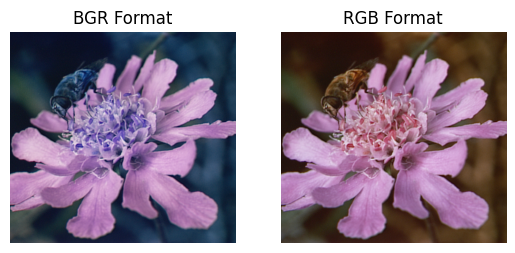

In [34]:
# Showing BGR and RGB side by side
plt.subplot(1,2,1)
plt.title("BGR Format")
plt.axis("off")
plt.imshow(img_bgr)

plt.subplot(1,2,2)
plt.title("RGB Format")
plt.axis("off")
plt.imshow(img_rgb)

# Resizing

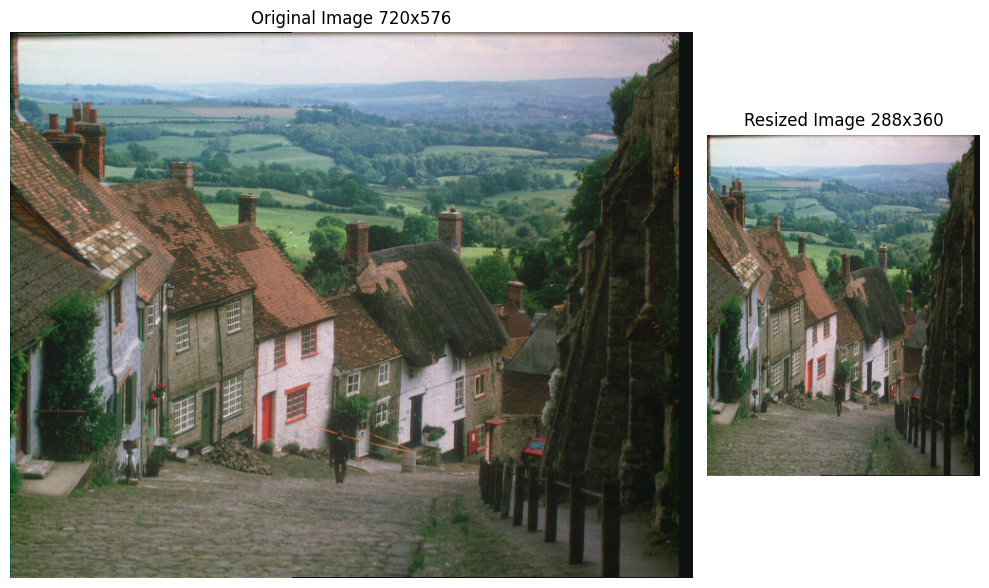

In [99]:
img_bgr = cv2.imread(f'{img_dir}/rgb/classic/goldhill.ppm')  # reading image | cv2 reads in BGR format
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # BGR to RGB

height, width, channels = img_rgb.shape  # shape of the original image
img_resized = cv2.resize(img_rgb, (height//2, width//2))  # downsizing by half

show_two_imgs_in_grid(
    img1 = img_rgb,
    img2 = img_resized,
    img1_title = f"Original Image {get_img_dim_str(img_rgb)}",
    img2_title = f"Resized Image {get_img_dim_str(img_resized)}",
)

# Crop

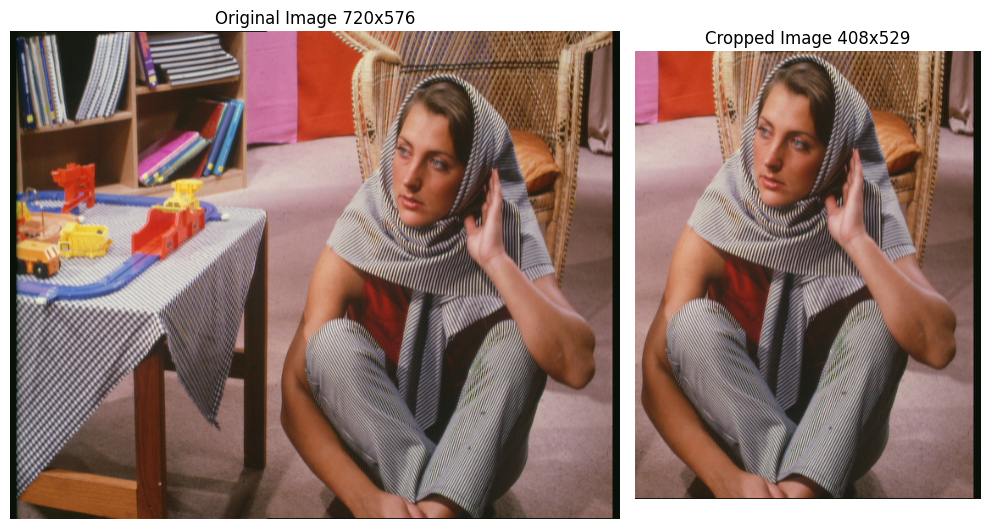

In [98]:
img_bgr = cv2.imread(f'{img_dir}/rgb/classic/barbara.ppm')  # reading image | cv2 reads in BGR format
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # BGR to RGB

img_cropped = img_rgb[47:, 312:]


show_two_imgs_in_grid(
    img1 = img_rgb,
    img2 = img_cropped,
    img1_title = f"Original Image {get_img_dim_str(img_rgb)}",
    img2_title = f"Cropped Image {get_img_dim_str(img_cropped)}",
)

# Blur
High Level Intuition: Bluring is about averaging!

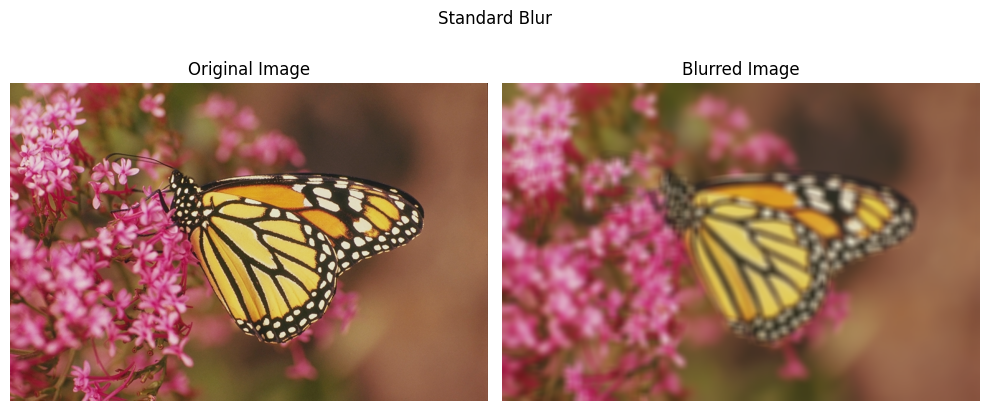

In [94]:
img_bgr = cv2.imread(f'{img_dir}/rgb/monarch.ppm')  # reading image | cv2 reads in BGR format
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)  # BGR to RGB

k = 13  # kernel size
img_blur = cv2.blur(img_rgb, (k, k))

show_two_imgs_in_grid(
    img1 = img_rgb,
    img2 = img_blur,
    img1_title = "Original Image",
    img2_title = "Blurred Image",
    fig_title="Standard Blur"
)

# HELPING METHODS

In [95]:
def show_two_imgs_in_grid(img1, img2, img1_title="", img2_title="", fig_title=""):
    fig = plt.figure(figsize=(10, 6))

    # Calculate width ration between image dimensions
    width_ratio = img1.shape[1] / img2.shape[1]

    # Create GridSpec with 1 row and 2 columns with custom with ratios
    gs = gridspec.GridSpec(1, 2, width_ratios=[width_ratio, 1])

    # Title of the figure
    fig.suptitle(fig_title, y=0.86)

    # Plot first image
    ax1 = plt.subplot(gs[0])
    ax1.imshow(img1)
    ax1.axis('off')
    ax1.set_title(img1_title if len(img1_title) > 0 else f'Image 1: {img1.shape[1]}x{img1.shape[0]}')

    # Plot second image
    ax2 = plt.subplot(gs[1])
    ax2.imshow(img2)
    ax2.axis('off')
    ax2.set_title(img2_title if len(img2_title) > 0 else f'Image 2: {img2.shape[1]}x{img2.shape[0]}')

    plt.tight_layout()
    plt.show()

def get_img_dim_str(_img):
    return f'{_img.shape[1]}x{_img.shape[0]}'